In [2]:
import igraph as ig
import networkx as nx
import csv
import pandas as pd
import dask.dataframe as dd 
import matplotlib.pyplot as plt


In [3]:
# App Name
# app_name = "montage-pegasus-2mass-2deg-4node" #cosmoflow cm1
# app_name = "1000_genome_pegasus_node_16"
# app_name = "cm1"
# app_name = "deepspeed-dlio-step100"
app_name = "deepspeed-dlio-scr-step100"
# app_name = "bert"
# app_name = "unet3d"
# app_name = "resnet50"
cp_dir = "/p/lustre3/pandey2/logs/Results_Checkpoint/dataflow/"+app_name+"/"

In [4]:
fhash_dir = "/p/lustre3/pandey2/logs/Results_Checkpoint/fhash/"+app_name+"/*.parquet"
fhash = dd.read_parquet(fhash_dir)
def getFilename(hash_value, fhash_df):
    result = fhash_df.query(f"hash == '{hash_value}'").compute()
    return result['name'].values

# Lvl3 

In [5]:

# create nx graph from original Networks

# Read the CSV file
df1 = pd.read_csv(cp_dir+"l3.csv", header=None, delimiter=" ", names=['src', 'dest'])
G3 = nx.DiGraph()
edge_list = list(zip(df1['src'], df1['dest']))
G3.add_edges_from(edge_list)


In [6]:
df1.head()

,src,dest
0,corona200,1.8128740601322631e+19
1,corona200,1.5408137414968932e+19
2,corona200,1.2781963089169592e+19
3,corona200,1.1873632556176292e+19
4,corona200,2.1611473095434896e+17


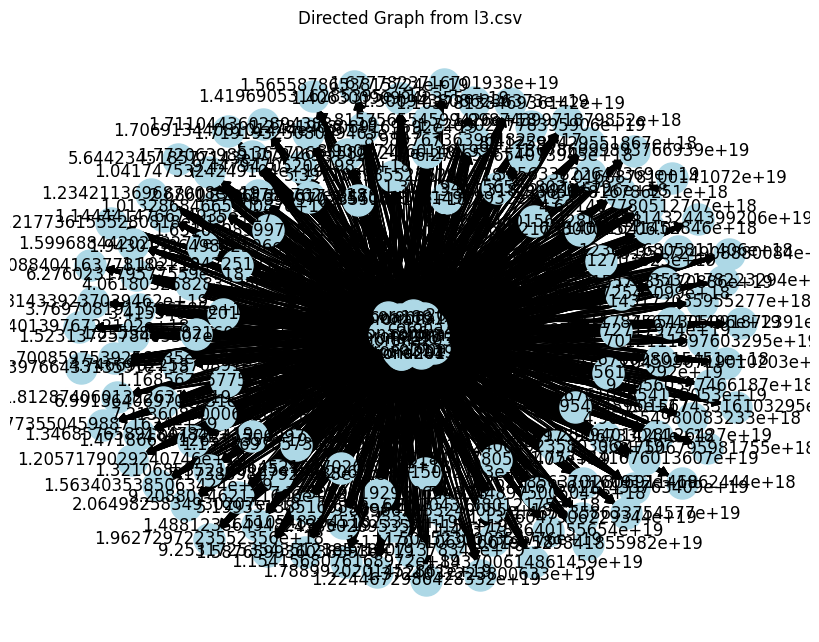

In [ ]:
# # Draw the graph with labels and arrows
# plt.figure(figsize=(8, 6))  # Set figure size
# pos = nx.spring_layout(G3)  # Layout for node positions

# nx.draw(G3, pos, with_labels=True, node_size=500, node_color='lightblue', 
#         arrows=True, arrowstyle='->', arrowsize=12)

# plt.title("Directed Graph from l3.csv")
# plt.axis('off')  # Hide axis
# plt.show()

In [8]:
df1.src.unique()

array(['corona200', '1.8128740601322631e+19', 'corona198', 'corona188',
       'corona205', 'corona204', 'corona199', 'corona192', 'corona201',
       'corona196', 'corona193', 'corona202', 'corona197', 'corona207',
       'corona191', 'corona213', 'corona206', '1.5408137414968932e+19',
       '1.2781963089169592e+19', '1.1873632556176292e+19',
       '2.1611473095434896e+17', '9.008840416377818e+18',
       '7.651395091872391e+18', '6.273653654073945e+18',
       '1.7573541676013607e+19', '4.746690225370891e+18',
       '8.645210270262127e+18', '4.691407780512707e+18',
       '4.454013976722102e+18', '6.114071641452846e+18',
       '4.964554980083233e+18', '3.4155408020167306e+18',
       '1.7069134408101444e+19', '1.0156743316103295e+19',
       '1.2066846615092703e+19', '6.276023179577559e+18',
       '1.385633822644369e+19', '8.023976643313591e+18',
       '1.4585026953571115e+19', '3.947506795981755e+18',
       '1.2244672986428332e+19', '5.836566816786251e+18',
       '1.77206398

In [ ]:
# print(getFilename('1.7827825848209795e+19',fhash)[0])
# print(getFilename('1.723427120640777e+18',fhash)[0])
# print(getFilename('1.4433171253546033e+19',fhash)[0])
# print(getFilename('9.061657290076685e+18',fhash)[0])
# print(getFilename('1.8128740601322631e+19',fhash)[0])

/usr/WS2/haridev/iopp/apps/dlio/hydra_log/megatron_deepspeed/2024-10-11-11-00-59/.hydra/config.yaml
/usr/WS2/haridev/iopp/apps/dlio/hydra_log/megatron_deepspeed/2024-10-11-11-00-59/.hydra/hydra.yaml
/usr/WS2/haridev/iopp/apps/dlio/hydra_log/megatron_deepspeed/2024-10-11-11-00-59/.hydra/overrides.yaml
/usr/workspace/haridev/iopp/apps/dlio/output/megatron_deepspeed-2-step100-scr0-opt0_16_8/dlio.log
/dev/infiniband/rdma_cm


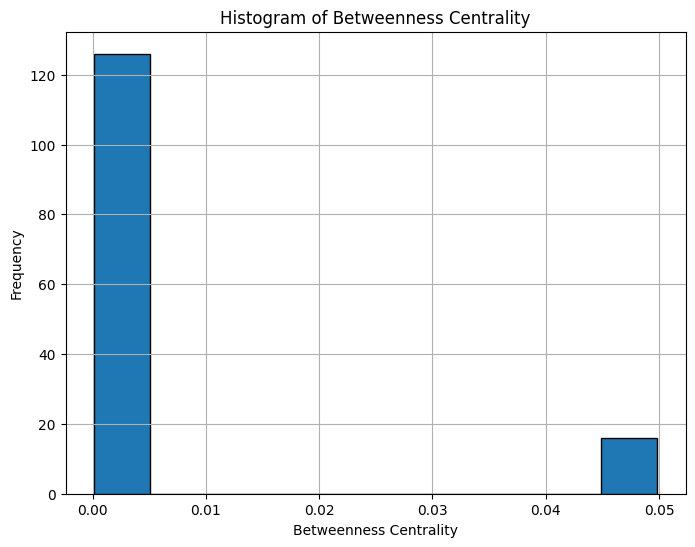

In [11]:
bet_centrality = nx.betweenness_centrality(G3, normalized=True, weight=None)

# Convert centrality dict to list of values
centrality_values = list(bet_centrality.values())

# Plot histogram
plt.figure(figsize=(8, 6))
plt.hist(centrality_values, bins=10, edgecolor='black')
plt.xlabel('Betweenness Centrality')
plt.ylabel('Frequency')
plt.title('Histogram of Betweenness Centrality')
plt.grid(True)
plt.show()

# Lvl1

In [12]:

# read parquet file groupby hostname and do analysis in each group
cp_dir+"lvl1/*.parquet"
df2 = dd.read_parquet(cp_dir+"lvl1/*.parquet")
df_singlehost = df2.reset_index().query("hostname == 'corona198'")
df_singlehost['pid'] = df_singlehost['pid'].apply(lambda x:f'p_{x}')
df_singlehost.groupby(['pid','fhash']).count().compute()


/usr/workspace/pandey2/DFT/envDFT/lib/python3.9/site-packages/dask/dataframe/core.py:4448: UserWarning: 
You did not provide metadata, so Dask is running your function on a small dataset to guess output types. It is possible that Dask will guess incorrectly.
To provide an explicit output types or to silence this message, please provide the `meta=` keyword, as described in the map or apply function that you are using.
  Before: .apply(func)
  After:  .apply(func, meta=('pid', 'object'))

  warnings.warn(meta_warning(meta))


index  hostname  ts
pid       fhash                                      
p_1466100 1.0004772509514418e+19      1         1   1
          1.0006791553651694e+18      1         1   1
          1.0007144073645988e+19      1         1   1
          1.0007647410633198e+19      1         1   1
          1.0014464458443002e+19      1         1   1
...                                 ...       ...  ..
p_1466107 9.981646443675834e+18       1         1   1
          9.986604913643057e+18       1         1   1
          9.993200746163778e+18       1         1   1
          9.998730799073241e+18       1         1   1
          9.99968097097672e+18        1         1   1

[28809 rows x 3 columns]

/usr/workspace/pandey2/DFT/envDFT/lib/python3.9/site-packages/dask/dataframe/core.py:8153: UserWarning: Insufficient elements for `head`. 5 elements requested, only 0 elements available. Try passing larger `npartitions` to `head`.
  warnings.warn(


In [13]:
print(getFilename('1.0004772509514418e+19',fhash)[0])
print(getFilename('1.0006791553651694e+18',fhash)[0])
print(getFilename('1.0007144073645988e+19',fhash)[0])
print(getFilename('1.0007647410633198e+19',fhash)[0])
print("****")
print(getFilename('9.981646443675834e+18',fhash)[0])
print(getFilename('9.986604913643057e+18',fhash)[0])
print(getFilename('9.993200746163778e+18',fhash)[0])
print(getFilename('9.998730799073241e+18',fhash)[0])

/dev/shm/torch_1466540_1117895773_266
/dev/shm/torch_1467612_1435602127_297
/dev/shm/torch_1467108_3758600217_102
/p/lustre3/haridev/megatron_deepspeed/checkpoint/layer-24-1-2300-48.pt
****
/l/ssd/haridev/scr/checkpoints/scr_megatron_deepspeed/haridev/scr.defjobid/scr.dataset.34/layer-30-1-2500-55.pt
/l/ssd/haridev/scr/checkpoints/scr_megatron_deepspeed/haridev/scr.defjobid/scr.dataset.22/.scr/reddesc.er.55.xor.grp_8_of_16.mem_7_of_8.redset
/dev/shm/torch_1467107_247527885_240
/dev/shm/torch_1467611_1058001604_484


In [60]:
df2.fhash.unique().compute()

0          1.000160077285259e+19
1         1.0002122491058502e+19
2         1.0002627534595666e+19
3          1.000313961871544e+19
4          1.000325340882533e+19
                   ...          
414210     9.995606683497929e+18
414211      9.99716537952927e+18
414212      9.99762866621407e+18
414213     9.998501463055022e+18
414214        9747829906740392.0
Name: fhash, Length: 414215, dtype: string

# Lvl2

In [14]:
# Step 2: Level 1 and 2 # per node basis
# read parquet file groupby hostname and do analysis in each group
df3 = dd.read_parquet(cp_dir+"lvl2/*.parquet")
df_singlehost = df3.reset_index().query("hostname == 'corona198'")
df_singlehost.head()
df_singlehost['pid_prod'] = df_singlehost['pid_prod'].apply(lambda x:f'p_{x}')
df_singlehost['pid_cons'] = df_singlehost['pid_cons'].apply(lambda x:f'p_{x}')
df_singlehost.compute()

/usr/workspace/pandey2/DFT/envDFT/lib/python3.9/site-packages/dask/dataframe/core.py:4448: UserWarning: 
You did not provide metadata, so Dask is running your function on a small dataset to guess output types. It is possible that Dask will guess incorrectly.
To provide an explicit output types or to silence this message, please provide the `meta=` keyword, as described in the map or apply function that you are using.
  Before: .apply(func)
  After:  .apply(func, meta=('pid_prod', 'object'))

  warnings.warn(meta_warning(meta))
/usr/workspace/pandey2/DFT/envDFT/lib/python3.9/site-packages/dask/dataframe/core.py:4448: UserWarning: 
You did not provide metadata, so Dask is running your function on a small dataset to guess output types. It is possible that Dask will guess incorrectly.
To provide an explicit output types or to silence this message, please provide the `meta=` keyword, as described in the map or apply function that you are using.
  Before: .apply(func)
  After:  .apply(func, 

,index,hostname,level_1,pid_prod,fhash,pid_cons,ts_prod,ts_cons
0,0,corona198,3192,p_1466100,1.1873632556176292e+19,p_1466101,26376340,26376686
1,1,corona198,3193,p_1466100,1.1873632556176292e+19,p_1466102,26376340,26378911
2,2,corona198,3194,p_1466100,1.1873632556176292e+19,p_1466103,26376340,26377060
3,3,corona198,3195,p_1466100,1.1873632556176292e+19,p_1466104,26376340,26375500
4,4,corona198,3196,p_1466100,1.1873632556176292e+19,p_1466105,26376340,26375761
...,...,...,...,...,...,...,...,...
282,282,corona198,27327,p_1466100,9.008840416377818e+18,p_1466103,155066155,155066243
283,283,corona198,27328,p_1466100,9.008840416377818e+18,p_1466104,155066155,155066242
284,284,corona198,27329,p_1466100,9.008840416377818e+18,p_1466105,155066155,155066242
285,285,corona198,27330,p_1466100,9.008840416377818e+18,p_1466106,155066155,155066242


In [15]:
G = nx.DiGraph()
for _, row in df_singlehost.iterrows():
    G.add_edge(row['pid_prod'], row['fhash'])
    G.add_edge(row['fhash'], row['pid_cons'])

In [16]:
f_nodes = [node for node in G.nodes if isinstance(node, str) and not node.startswith('p')]
f_nodes

['1.1873632556176292e+19',
 '1.2781963089169592e+19',
 '1.5408137414968932e+19',
 '1.8128740601322631e+19',
 '2.1611473095434896e+17',
 '9.008840416377818e+18']

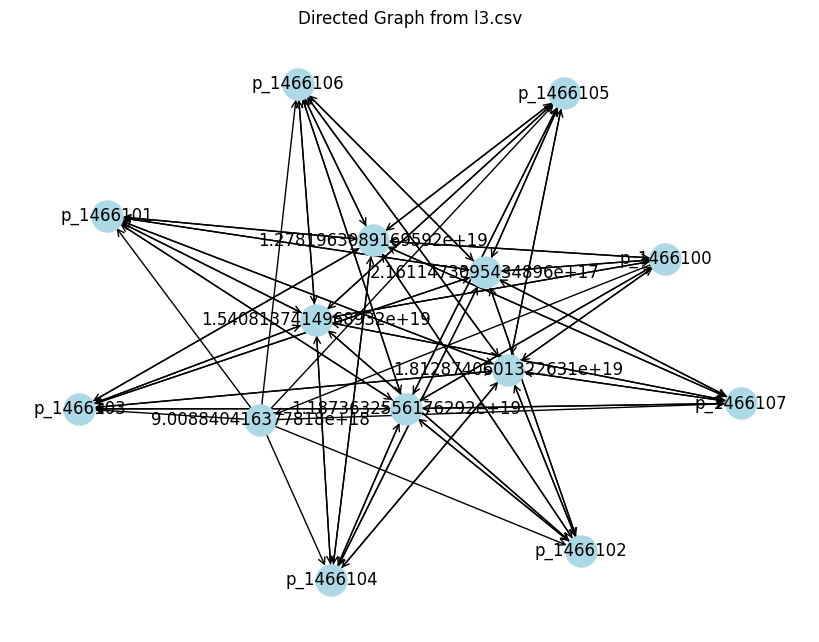

In [17]:
# Draw the graph with labels and arrows
plt.figure(figsize=(8, 6))  # Set figure size
pos = nx.spring_layout(G)  # Layout for node positions

nx.draw(G, pos, with_labels=True, node_size=500, node_color='lightblue', 
        arrows=True, arrowstyle='->', arrowsize=12)

plt.title("Directed Graph from l3.csv")
plt.axis('off')  # Hide axis
plt.show()

In [20]:
f = ['1.1873632556176292e+19','1.2781963089169592e+19','1.5408137414968932e+19','1.8128740601322631e+19','2.1611473095434896e+17','9.008840416377818e+18']
for files_hash in f:
    print(getFilename(files_hash,fhash)[0])


/usr/WS2/haridev/iopp/apps/dlio/hydra_log/megatron_deepspeed/2024-10-11-18-23-09/.hydra/hydra.yaml
/usr/WS2/haridev/iopp/apps/dlio/hydra_log/megatron_deepspeed/2024-10-11-18-23-09/.hydra/config.yaml
/usr/workspace/haridev/iopp/apps/dlio/output/megatron_deepspeed-2-step100-scr1-opt0_16_8_0_axl16/dlio.log
/dev/infiniband/rdma_cm
/usr/WS2/haridev/iopp/apps/dlio/hydra_log/megatron_deepspeed/2024-10-11-18-23-09/.hydra/overrides.yaml
/dev/shm/haridev/scr.defjobid/cindex.scrinfo


In [21]:
bet_centrality = nx.betweenness_centrality(G, normalized=True, weight=None)

# Display the centrality values
for node, centrality in bet_centrality.items():
    print(f"Node: {node}, Betweenness Centrality: {centrality:.6f}")

Node: p_1466100, Betweenness Centrality: 0.092949
Node: 1.1873632556176292e+19, Betweenness Centrality: 0.080556
Node: p_1466101, Betweenness Centrality: 0.021520
Node: p_1466102, Betweenness Centrality: 0.021520
Node: p_1466103, Betweenness Centrality: 0.021520
Node: p_1466104, Betweenness Centrality: 0.021520
Node: p_1466105, Betweenness Centrality: 0.021520
Node: p_1466106, Betweenness Centrality: 0.021520
Node: p_1466107, Betweenness Centrality: 0.021520
Node: 1.2781963089169592e+19, Betweenness Centrality: 0.080556
Node: 1.5408137414968932e+19, Betweenness Centrality: 0.080556
Node: 1.8128740601322631e+19, Betweenness Centrality: 0.080556
Node: 2.1611473095434896e+17, Betweenness Centrality: 0.080556
Node: 9.008840416377818e+18, Betweenness Centrality: 0.007479


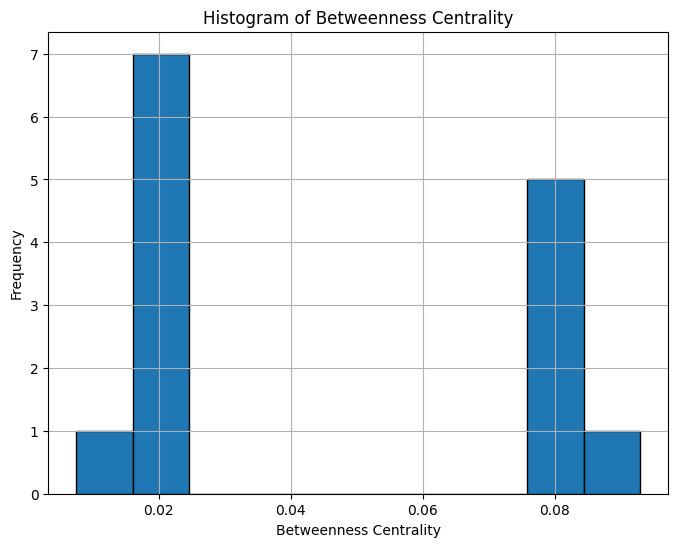

In [22]:
bet_centrality = nx.betweenness_centrality(G, normalized=True, weight=None)

# Convert centrality dict to list of values
centrality_values = list(bet_centrality.values())

# Plot histogram
plt.figure(figsize=(8, 6))
plt.hist(centrality_values, bins=10, edgecolor='black')
plt.xlabel('Betweenness Centrality')
plt.ylabel('Frequency')
plt.title('Histogram of Betweenness Centrality')
plt.grid(True)
plt.show()